In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pickle

# Optional XGBoost
try:
    from xgboost import XGBRegressor
    _HAS_XGB = True
except:
    _HAS_XGB = False

DATA_PATH = Path("crop_yeild_dataset1.csv")
TARGET_COL = "Yield_kg_ha"
RANDOM_STATE = 42


In [2]:
def cap_iqr(df, cols):
    df = df.copy()
    for c in cols:
        if c not in df.columns: 
            continue
        series = pd.to_numeric(df[c], errors='coerce')
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[c] = series.clip(lower=lower, upper=upper)
    return df


In [3]:
print("Loading data from:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Strip whitespace
df.columns = [c.strip() for c in df.columns]
# ---- Yield Normalization Patch ----
df["Crop_Mean_Yield"] = df.groupby("Crop")["Yield_kg_ha"].transform("mean")
df["Yield_Normalized"] = df["Yield_kg_ha"] / df["Crop_Mean_Yield"]



Loading data from: crop_yeild_dataset1.csv
Shape: (5000, 13)
Columns: ['State', 'District', 'Crop', 'Seed_Variety', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Soil_Moisture', 'Humidity', 'Irrigation_Count', 'Previous_Yield_kg_ha', 'Area_Hectares', 'Yield_kg_ha']


In [4]:
# ------------------------------------------
# YIELD NORMALIZATION PER CROP
# ------------------------------------------

# Mean yield per crop
crop_mean_yield = df.groupby("Crop")["Yield_kg_ha"].transform("mean")

# Normalized target (ratio)
df["Yield_Normalized"] = df["Yield_kg_ha"] / crop_mean_yield

print(df[["Crop", "Yield_kg_ha", "Yield_Normalized"]].head())


     Crop  Yield_kg_ha  Yield_Normalized
0    Rice      5158.61          1.071348
1   Wheat      3435.46          0.900472
2  Cotton      1152.10          0.746282
3    Rice      4202.50          0.872782
4   Wheat      3896.78          1.021389


In [5]:
# ---- Extract unique categorical options from dataset ----

df_categories = df.copy()

# Clean column names
df_categories.columns = [c.strip() for c in df_categories.columns]

state_list = sorted(df_categories["State"].dropna().unique().tolist())
district_list = sorted(df_categories["District"].dropna().unique().tolist())
crop_list = sorted(df_categories["Crop"].dropna().unique().tolist())
seed_variety_list = sorted(df_categories["Seed_Variety"].dropna().unique().tolist())

# Create mapping for districts by state
state_to_districts = (
    df_categories.groupby("State")["District"]
    .unique()
    .apply(lambda x: sorted(list(x)))
    .to_dict()
)

print("States:", state_list[:10])
print("Districts:", district_list[:10])
print("Crops:", crop_list[:10])
print("Seed Varieties:", seed_variety_list[:10])


States: ['Andhra Pradesh', 'Karnataka', 'Maharashtra', 'Punjab', 'Telangana', 'Uttar Pradesh']
Districts: ['Agra', 'Amritsar', 'Aurangabad', 'Belagavi', 'Bengaluru Rural', 'Chittoor', 'Dharwad', 'Guntur', 'Jalandhar', 'Kanpur']
Crops: ['Cotton', 'Maize', 'Rice', 'Sugarcane', 'Wheat']
Seed Varieties: ['Bollgard-II (Maharashtra)', 'Co-0238 (UP/North India)', 'Co-86032 (Tamil Nadu/AP)', 'Co-94012 (South India)', 'HD-2967 (North-West India)', 'HQPM-1 (Karnataka/AP)', 'HW-2045 (North India)', 'IR-64 (Andhra/Telangana)', 'JKCH-1947 (Gujarat/MH)', 'Kaveri-50 (South India)']


In [6]:
if TARGET_COL not in df.columns:
    candidates = [c for c in df.columns if "yield" in c.lower()]
    if len(candidates):
        TARGET_COL = candidates[0]
        print("Auto-detected target:", TARGET_COL)
    else:
        raise ValueError("Target column not found.")


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])


Numeric: ['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Soil_Moisture', 'Humidity', 'Irrigation_Count', 'Previous_Yield_kg_ha', 'Area_Hectares', 'Crop_Mean_Yield', 'Yield_Normalized']
Categorical: ['State', 'District', 'Crop', 'Seed_Variety']


In [8]:
df = cap_iqr(df, numeric_cols + [TARGET_COL])


In [9]:
df = df.dropna(subset=[TARGET_COL])

X = df.drop(columns=[TARGET_COL])
y = df["Yield_Normalized"].astype(float)


numeric_features = numeric_cols
categorical_features = categorical_cols


Data Shape: (5000, 15)

Column Types:
State                    object
District                 object
Crop                     object
Seed_Variety             object
Rainfall_mm             float64
Temperature_C           float64
Soil_pH                 float64
Soil_Moisture           float64
Humidity                float64
Irrigation_Count        float64
Previous_Yield_kg_ha    float64
Area_Hectares           float64
Yield_kg_ha             float64
Crop_Mean_Yield         float64
Yield_Normalized        float64
dtype: object

Missing Values:
State                   0
District                0
Crop                    0
Seed_Variety            0
Rainfall_mm             0
Temperature_C           0
Soil_pH                 0
Soil_Moisture           0
Humidity                0
Irrigation_Count        0
Previous_Yield_kg_ha    0
Area_Hectares           0
Yield_kg_ha             0
Crop_Mean_Yield         0
Yield_Normalized        0
dtype: int64


,State,District,Crop,Seed_Variety,Rainfall_mm,Temperature_C,Soil_pH,Soil_Moisture,Humidity,Irrigation_Count,Previous_Yield_kg_ha,Area_Hectares,Yield_kg_ha,Crop_Mean_Yield,Yield_Normalized
0,Uttar Pradesh,Lucknow,Rice,MTU-1010 (AP/Telangana),1024.178538,27.016075,6.89,13.0,59.0,3.0,4885.0,2.86,5158.61,4815.065340,1.071348
1,Punjab,Amritsar,Wheat,HW-2045 (North India),468.770542,25.531994,5.89,17.3,58.0,7.0,3028.0,0.71,3435.46,3815.177121,0.900472
2,Uttar Pradesh,Lucknow,Cotton,Bollgard-II (Maharashtra),612.251606,28.814943,6.14,29.9,59.0,3.0,3085.0,3.48,1152.10,2315.344793,0.746282
3,Karnataka,Belagavi,Rice,IR-64 (Andhra/Telangana),952.215899,20.641155,5.70,39.0,54.0,4.0,6387.0,2.11,4202.50,4815.065340,0.872782
4,Andhra Pradesh,Krishna,Wheat,HD-2967 (North-West India),985.904572,21.329359,6.69,10.4,73.0,6.0,4599.0,4.38,3896.78,3815.177121,1.021389



Statistical Summary:


,Rainfall_mm,Temperature_C,Soil_pH,Soil_Moisture,Humidity,Irrigation_Count,Previous_Yield_kg_ha,Area_Hectares,Yield_kg_ha,Crop_Mean_Yield,Yield_Normalized
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,895.263303,27.537605,6.499590,23.988380,64.70860,3.560000,4251.675200,2.752832,4679.136108,4339.216771,0.999052
std,243.580317,3.514370,0.573631,8.930513,9.95968,2.275486,1598.304109,1.294004,2402.931959,1310.909172,0.168083
min,259.651610,18.262147,4.998750,8.000000,38.50000,0.000000,1500.000000,0.500000,100.000000,2315.344793,0.641885
25%,735.774049,25.198689,6.127500,16.600000,58.00000,2.000000,2889.750000,1.640000,3252.370000,3815.177121,0.909214
50%,891.928240,27.540266,6.510000,23.800000,65.00000,4.000000,4259.000000,2.770000,4344.670000,4319.643555,0.999715
75%,1053.189008,29.823050,6.880000,31.525000,71.00000,6.000000,5638.000000,3.870000,5419.765000,4815.065340,1.087433
max,1529.311447,36.759592,8.008750,40.000000,90.50000,7.000000,6999.000000,5.000000,8670.857500,6314.897668,1.354762


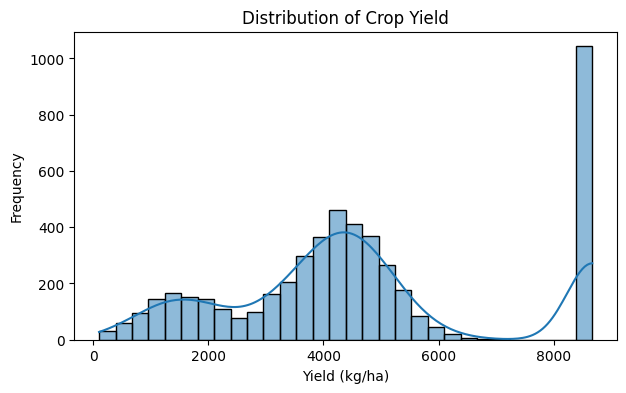

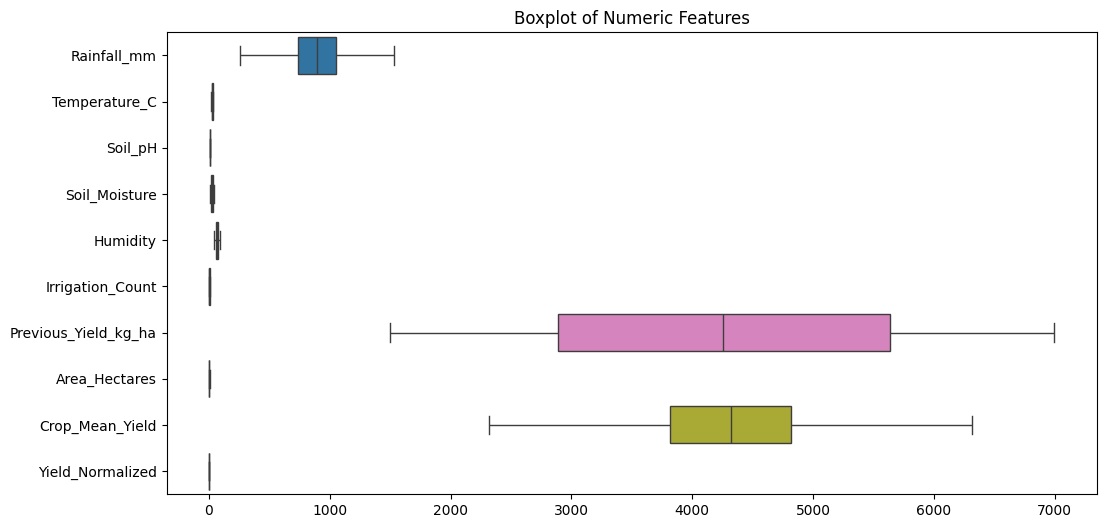

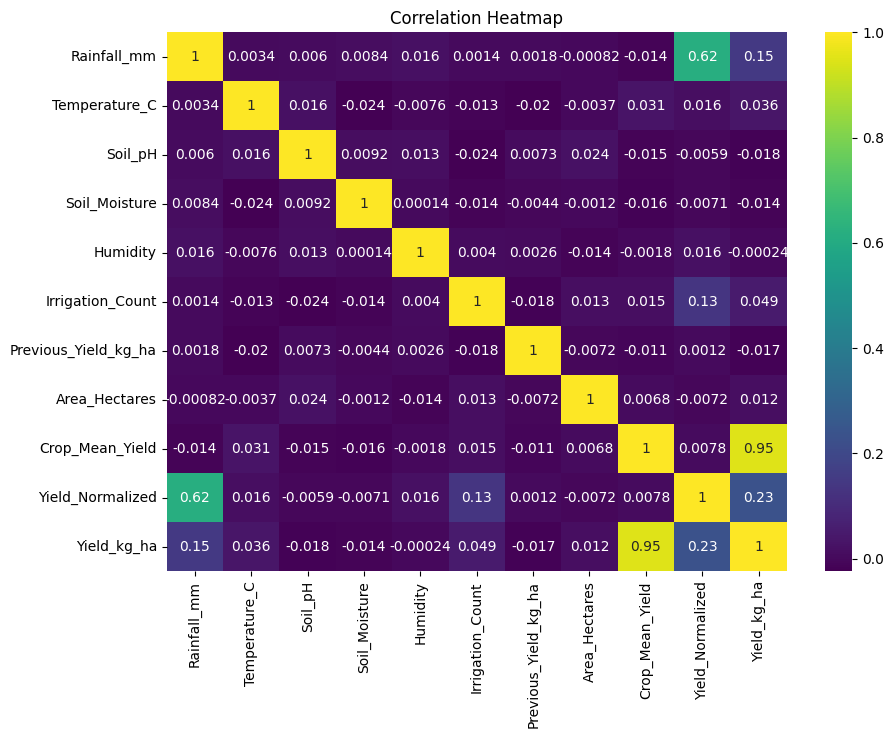

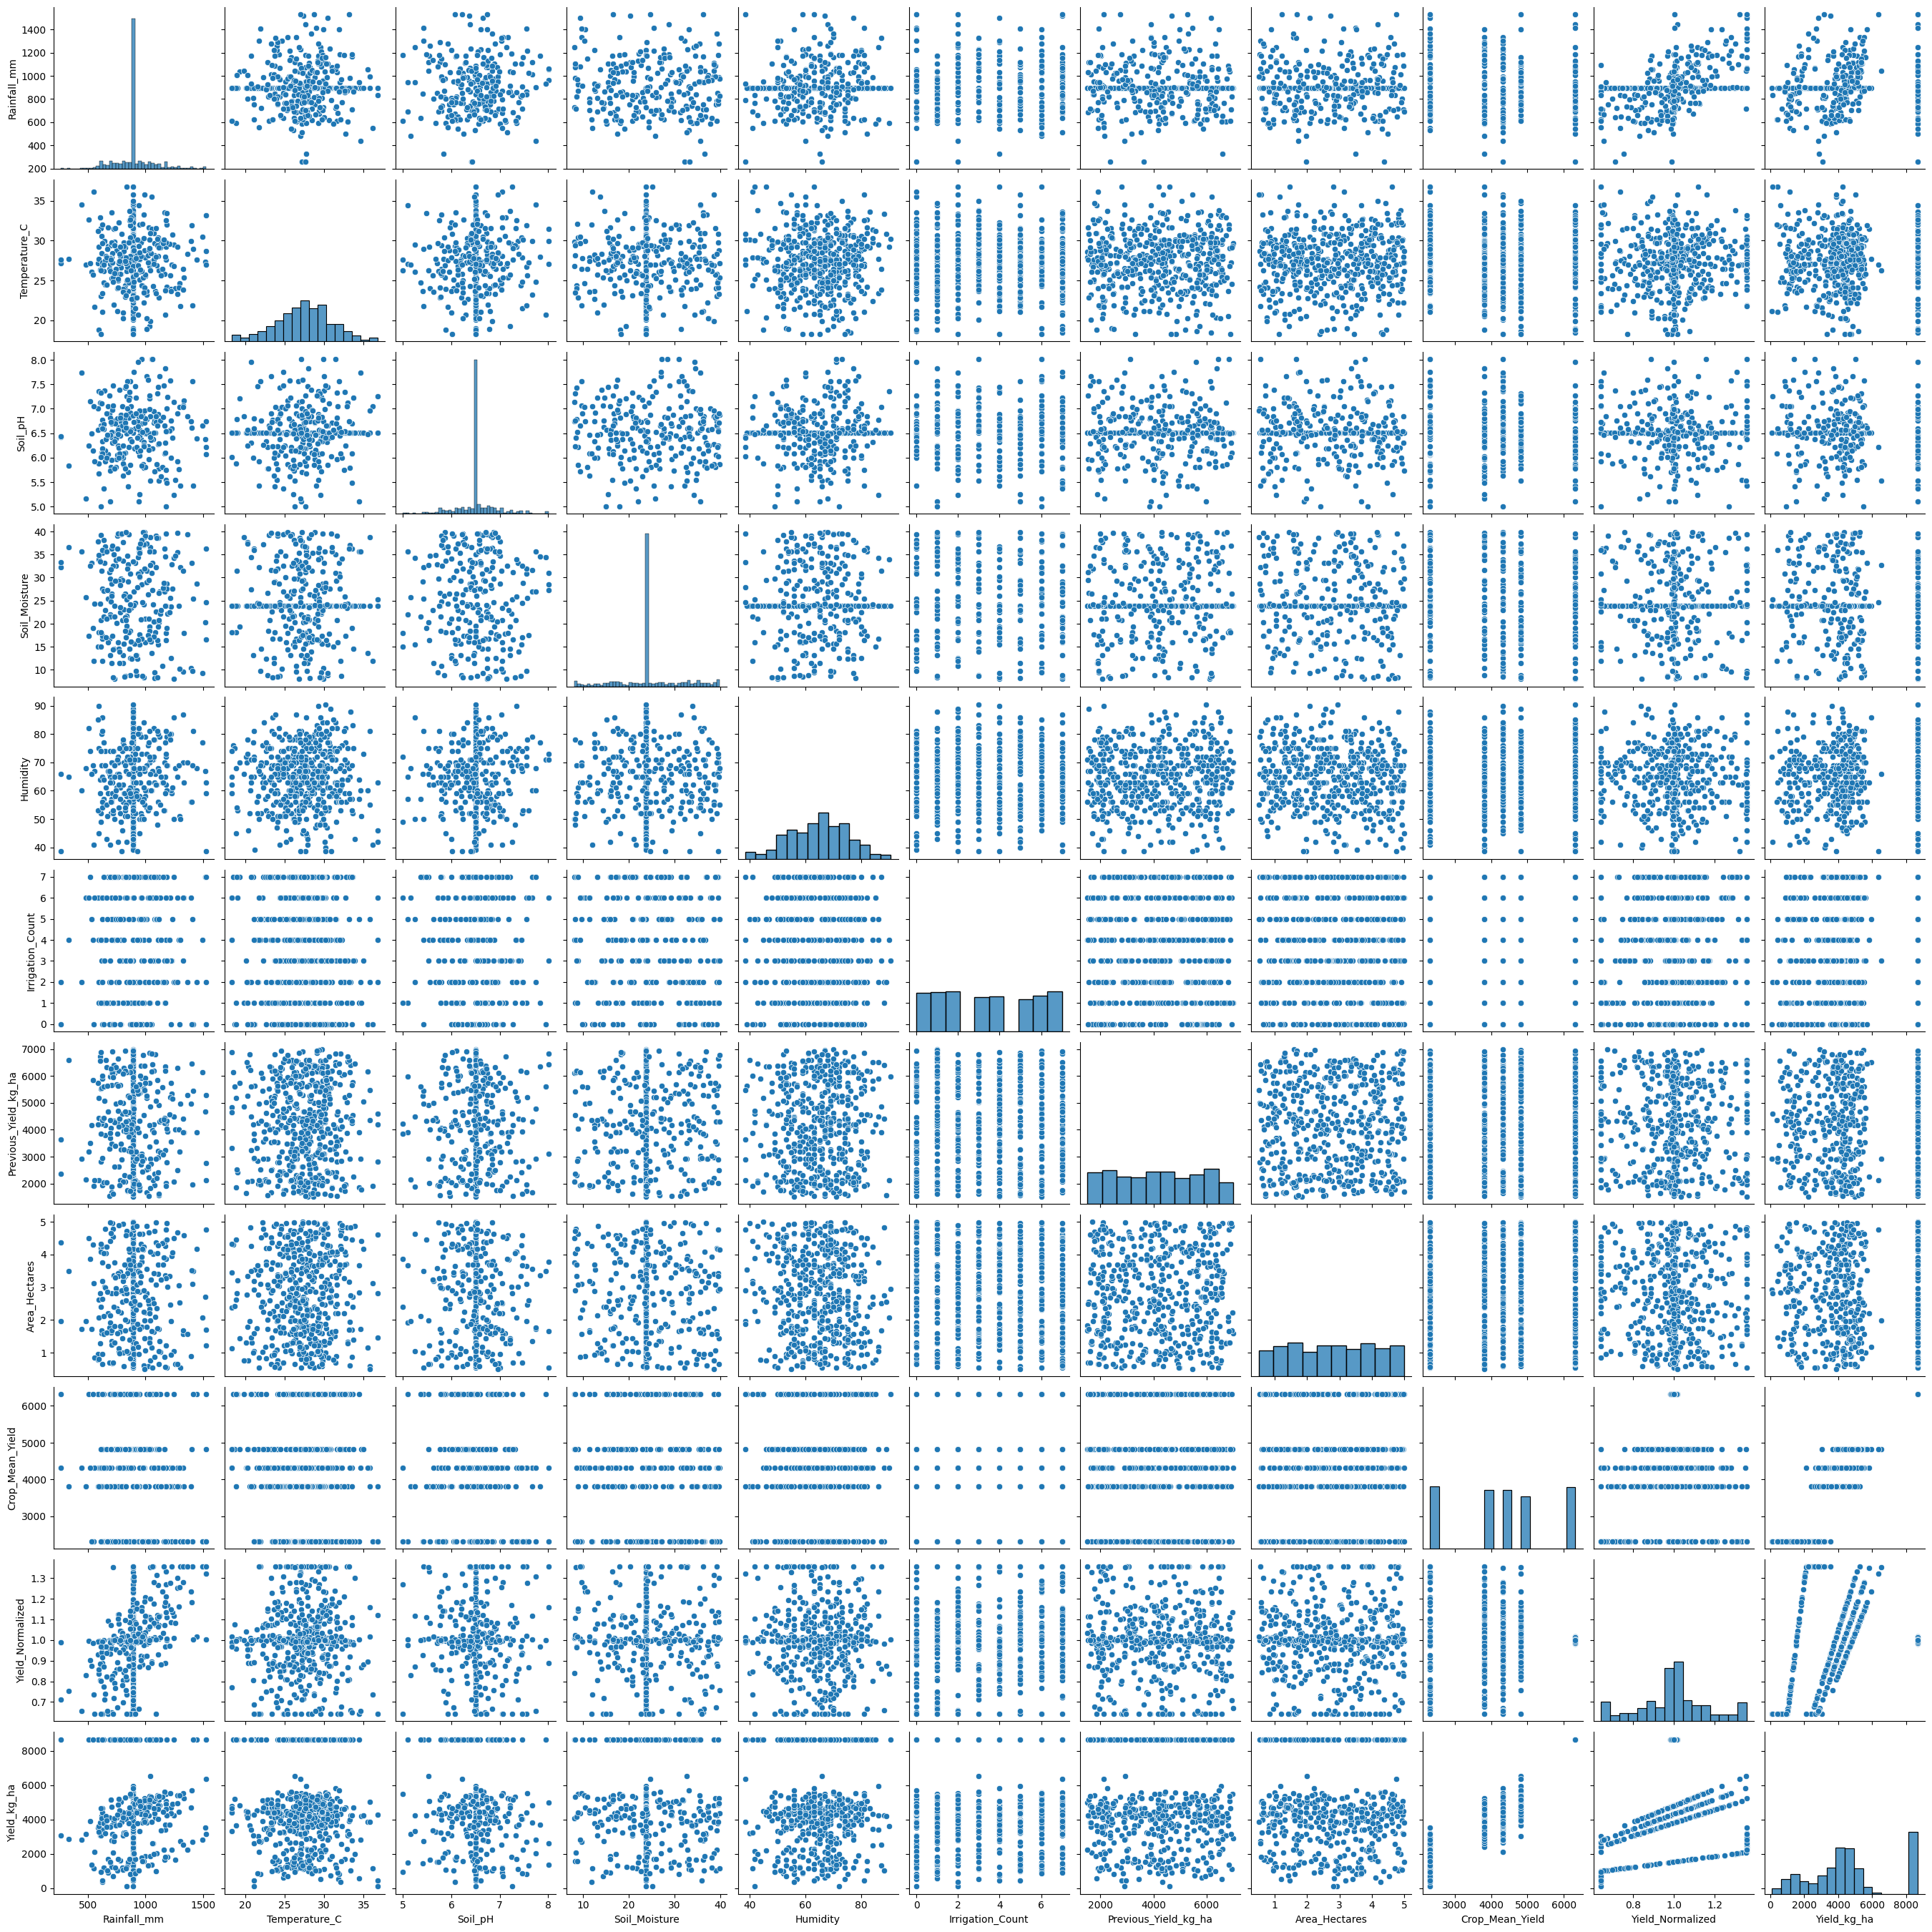

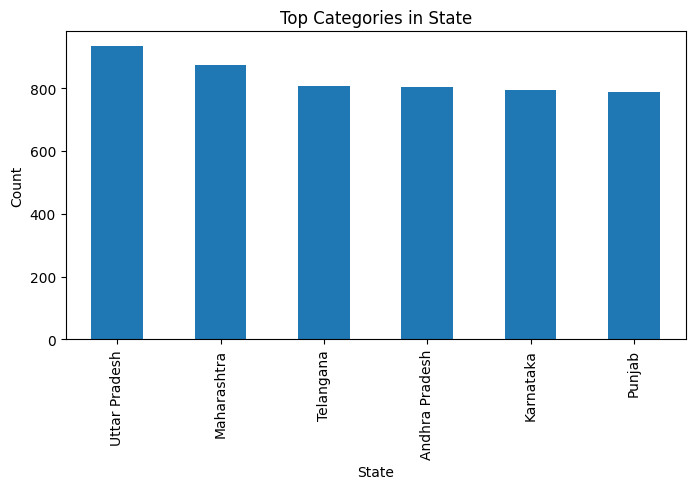

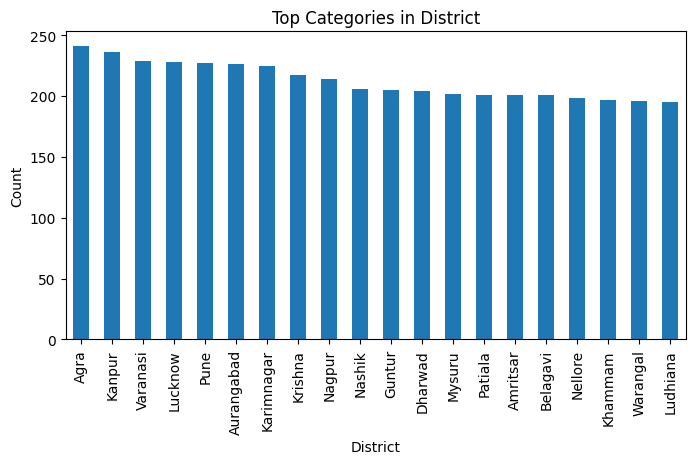

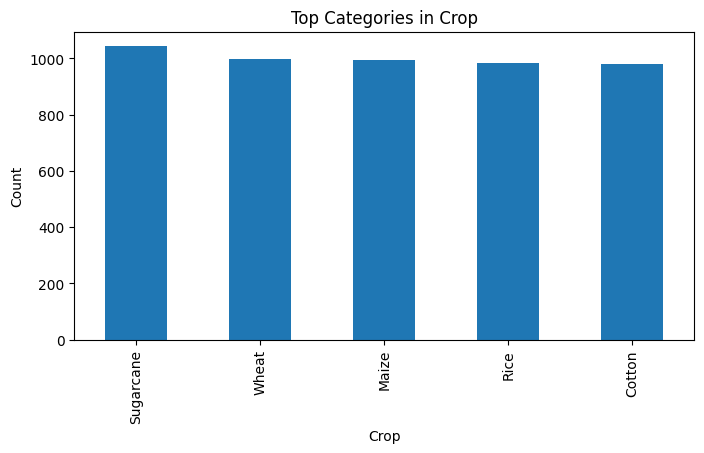

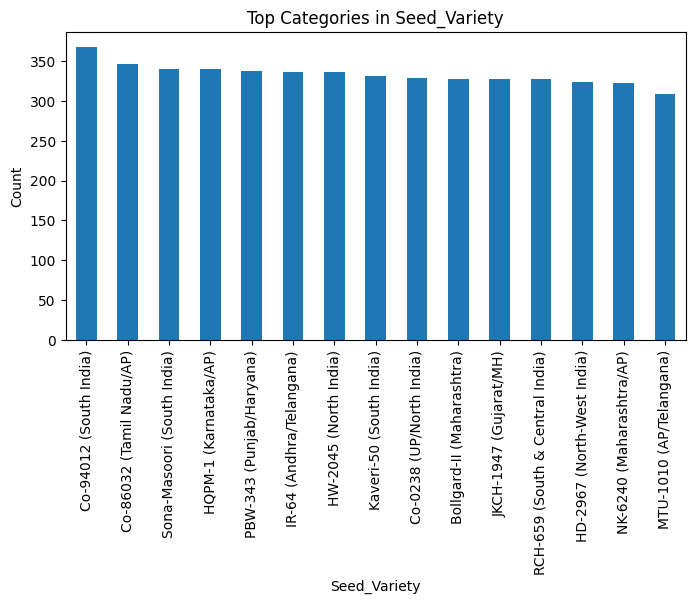

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- BASIC INFO ----------
print("Data Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

display(df.head())

# ---------- NUMERICAL SUMMARY ----------
print("\nStatistical Summary:")
display(df.describe())

# ---------- DISTRIBUTION OF TARGET ----------
plt.figure(figsize=(7,4))
sns.histplot(df[TARGET_COL], kde=True, bins=30)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Frequency")
plt.show()

# ---------- BOX PLOTS FOR NUMERIC FEATURES ----------
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplot of Numeric Features")
plt.show()

# ---------- CORRELATION HEATMAP ----------
plt.figure(figsize=(10,7))
corr = df[numeric_cols + [TARGET_COL]].corr()
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

# ---------- PAIRPLOT (OPTIONAL: Use on small subset to avoid heavy compute) ----------
sample_df = df.sample(500, random_state=42)  # reduce load
sns.pairplot(sample_df[numeric_cols + [TARGET_COL]])
plt.show()

# ---------- CATEGORICAL FEATURE COUNTS ----------
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.ylabel("Count")
    plt.show()


In [11]:
# Handle different sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

X_train_t.shape


(4000, 60)

In [13]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
}

if _HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, eval_metric='rmse')


In [14]:
results = []

for name, model in models.items():
    print("\nTraining:", name)
    model.fit(X_train_t, y_train)
    preds = model.predict(X_test_t)

    mse = mean_squared_error(y_test, preds)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df



Training: LinearRegression

Training: RandomForest

Training: GradientBoosting

Training: XGBoost


,Model,RMSE,MSE,MAE,R2
0,LinearRegression,1.441153e-16,2.076923e-32,9.869883e-17,1.000000
1,RandomForest,2.335920e-04,5.456520e-08,1.197268e-04,0.999998
3,XGBoost,1.198934e-03,1.437444e-06,8.124296e-04,0.999953
2,GradientBoosting,1.379749e-03,1.903708e-06,9.450122e-04,0.999937


In [15]:
cv_results = []

for name, model in models.items():
    try:
        scores = -1 * cross_val_score(model, preprocessor.transform(X), y, cv=5,
                                      scoring="neg_root_mean_squared_error")
        cv_results.append({
            "Model": name,
            "CV_RMSE_mean": scores.mean(),
            "CV_RMSE_std": scores.std()
        })
    except:
        cv_results.append({"Model": name, "CV_RMSE_mean": None, "CV_RMSE_std": None})

pd.DataFrame(cv_results).sort_values("CV_RMSE_mean")


,Model,CV_RMSE_mean,CV_RMSE_std
0,LinearRegression,1.953218e-16,5.869015e-17
1,RandomForest,2.465181e-04,2.029627e-05
3,XGBoost,1.178415e-03,6.875595e-05
2,GradientBoosting,1.362797e-03,3.977896e-05


In [16]:
# ----------------------------------------------
# ENSEMBLE LEARNING — STACKING REGRESSOR
# Base Model: GradientBoosting
# Meta Model: RandomForest
# ----------------------------------------------

from sklearn.ensemble import StackingRegressor

# Define base estimators
base_estimators = [
    ('gbr', GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE))
]

# Meta model (final estimator)
meta_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE
)

# Create stacking regressor
stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_model,
    passthrough=True
)

print("\nTraining Stacking Ensemble (GBR → RF)...")
stack_model.fit(X_train_t, y_train)

# Predictions
stack_preds = stack_model.predict(X_test_t)

# Metrics
stack_mse = mean_squared_error(y_test, stack_preds)
stack_rmse = stack_mse ** 0.5
stack_mae = mean_absolute_error(y_test, stack_preds)
stack_r2 = r2_score(y_test, stack_preds)

print("\nEnsemble Model (Stacking Regressor) Performance:")
print(f"RMSE: {stack_rmse:.4f}")
print(f"MSE : {stack_mse:.4f}")
print(f"MAE : {stack_mae:.4f}")
print(f"R²  : {stack_r2:.4f}")

# Add to results DataFrame for comparison (Pandas 2.0 compatible)
new_row = pd.DataFrame([{
    "Model": "Stacking (GBR→RF)",
    "RMSE": stack_rmse,
    "MSE": stack_mse,
    "MAE": stack_mae,
    "R2": stack_r2
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df



Training Stacking Ensemble (GBR → RF)...

Ensemble Model (Stacking Regressor) Performance:
RMSE: 0.0003
MSE : 0.0000
MAE : 0.0001
R²  : 1.0000


,Model,RMSE,MSE,MAE,R2
0,LinearRegression,1.441153e-16,2.076923e-32,9.869883e-17,1.000000
1,RandomForest,2.335920e-04,5.456520e-08,1.197268e-04,0.999998
2,Stacking (GBR→RF),2.705333e-04,7.318827e-08,1.417439e-04,0.999998
3,XGBoost,1.198934e-03,1.437444e-06,8.124296e-04,0.999953
4,GradientBoosting,1.379749e-03,1.903708e-06,9.450122e-04,0.999937


In [17]:
best_name = results_df.iloc[0]["Model"]

# Build FULL pipeline (preprocessor + best regressor)
best_model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", models[best_name])
])

# Crop means for denormalization
crop_means = df.groupby("Crop")["Yield_kg_ha"].mean().to_dict()

save_obj = {
    "model": best_model_pipeline,   # IMPORTANT — full pipeline
    "features": X.columns.tolist(),
    "crop_means": crop_means
}

with open("best_crop_yield_model.pkl", "wb") as f:
    pickle.dump(save_obj, f)

print("Saved full pipeline model with crop means!")


Saved full pipeline model with crop means!


In [18]:
def predict_from_pkl(input_dict):
    model_data = pickle.load(open("best_crop_yield_model.pkl", "rb"))
    model = model_data["model"]
    features = model_data["features"]
    crop_means = model_data["crop_means"]

    # Prepare input row
    df_input = pd.DataFrame([input_dict], columns=features)

    # Predict normalized yield
    normalized_pred = model.predict(df_input)[0]

    # Convert to actual yield
    crop = input_dict["Crop"]
    mean_val = crop_means[crop]

    return normalized_pred * mean_val


In [19]:
def convert_farmer_inputs(input_dict):
    """
    Converts farmer-friendly categorical inputs (High/Moderate/Low etc.)
    into numeric mid-point values that your ML model understands.
    """

    converted = {}

    # ------------ RAINFALL ------------
    if "Rainfall" in input_dict:
        rain = input_dict["Rainfall"].lower()
        if rain == "low":
            converted["Rainfall_mm"] = 50       # example midpoint
        elif rain == "moderate":
            converted["Rainfall_mm"] = 150
        elif rain == "high":
            converted["Rainfall_mm"] = 300
        else:
            converted["Rainfall_mm"] = None

    # ------------ TEMPERATURE ------------
    if "Temperature" in input_dict:
        temp = input_dict["Temperature"].lower()
        if temp == "low":
            converted["Temperature_C"] = 15
        elif temp == "moderate":
            converted["Temperature_C"] = 25
        elif temp == "high":
            converted["Temperature_C"] = 35
        else:
            converted["Temperature_C"] = None

    # ------------ SOIL MOISTURE ------------
    if "Moisture" in input_dict:
        mos = input_dict["Moisture"].lower()
        if mos == "low":
            converted["Soil_Moisture"] = 10
        elif mos == "moderate":
            converted["Soil_Moisture"] = 30
        elif mos == "high":
            converted["Soil_Moisture"] = 60
        else:
            converted["Soil_Moisture"] = None

    # ------------ HUMIDITY ------------
    if "HumidityLevel" in input_dict:
        hum = input_dict["HumidityLevel"].lower()
        if hum == "low":
            converted["Humidity"] = 30
        elif hum == "moderate":
            converted["Humidity"] = 55
        elif hum == "high":
            converted["Humidity"] = 80
        else:
            converted["Humidity"] = None

    # ------------ IRRIGATION ------------
    if "Irrigation" in input_dict:
        irr = input_dict["Irrigation"].lower()
        if irr == "low":
            converted["Irrigation_Count"] = 1
        elif irr == "moderate":
            converted["Irrigation_Count"] = 3
        elif irr == "high":
            converted["Irrigation_Count"] = 6
        else:
            converted["Irrigation_Count"] = None

    # ------------ SOIL pH ------------
    if "Soil_pH_Level" in input_dict:
        ph = input_dict["Soil_pH_Level"].lower()
        if ph == "acidic":
            converted["Soil_pH"] = 5.5
        elif ph == "neutral":
            converted["Soil_pH"] = 7.0
        elif ph == "alkaline":
            converted["Soil_pH"] = 8.5
        else:
            converted["Soil_pH"] = None

    # ------------ DIRECT FEATURES ------------
    # If any exact values exist (area, previous yield, etc.), pass them forward
    for key in input_dict:
        if key not in converted:
            converted[key] = input_dict[key]

    return converted


In [20]:
def predict_for_farmer(raw_input):
    """
    Accepts farmer-friendly input such as High/Moderate/Low values
    converts them to numeric ranges and predicts yield.
    """
    converted_input = convert_farmer_inputs(raw_input)
    return predict_from_pkl(converted_input)

# Example farmer input:
farmer_data = {
    "State": "Karnataka",
    "District": "Bengaluru",
    "Crop": "Rice",
    "Seed_Variety": "Hybrid",
    "Rainfall": "High",
    "Temperature": "Moderate",
    "Moisture": "High",
    "HumidityLevel": "Moderate",
    "Irrigation": "Low",
    "Soil_pH_Level": "Neutral",
    "Previous_Yield_kg_ha": 2500,
    "Area_Hectares": 3
}

print("Predicted Yield:", predict_for_farmer(farmer_data))


Predicted Yield: 4813.55927661759
